=== PHASE 1: DATA UNDERSTANDING ===
Total Transactions: 5000
Missing Values:
Transaction_ID        0
User_ID               0
Account_Age_Days      0
Transaction_Amount    0
Hour_of_Day           0
Device_Changes        0
Daily_Freq            0
Is_Fraud              0
dtype: int64
Suspicious (Fraud) Transactions: 414 (8.28%)

=== PHASE 2: DESCRIPTIVE STATISTICS ===
          Transaction_Amount  Daily_Freq  Account_Age_Days
mean             1514.059934    3.010600        180.260800
median           1059.920000    3.000000        180.500000
std              1519.949394    1.736517        104.963673
<lambda>          460.085000    2.000000         90.000000
<lambda>         2072.672500    4.000000        272.000000

Average Transaction Amount: ₹1514.06
Average Daily Transaction Frequency: 3.01
Transaction Amount Skewness: 2.20

=== PHASE 3: OUTLIER DETECTION ===
IQR Upper Bound threshold: ₹4491.55
Outliers detected via IQR: 251
Outliers detected via Z-score (> 3 std dev): 90
Statistically

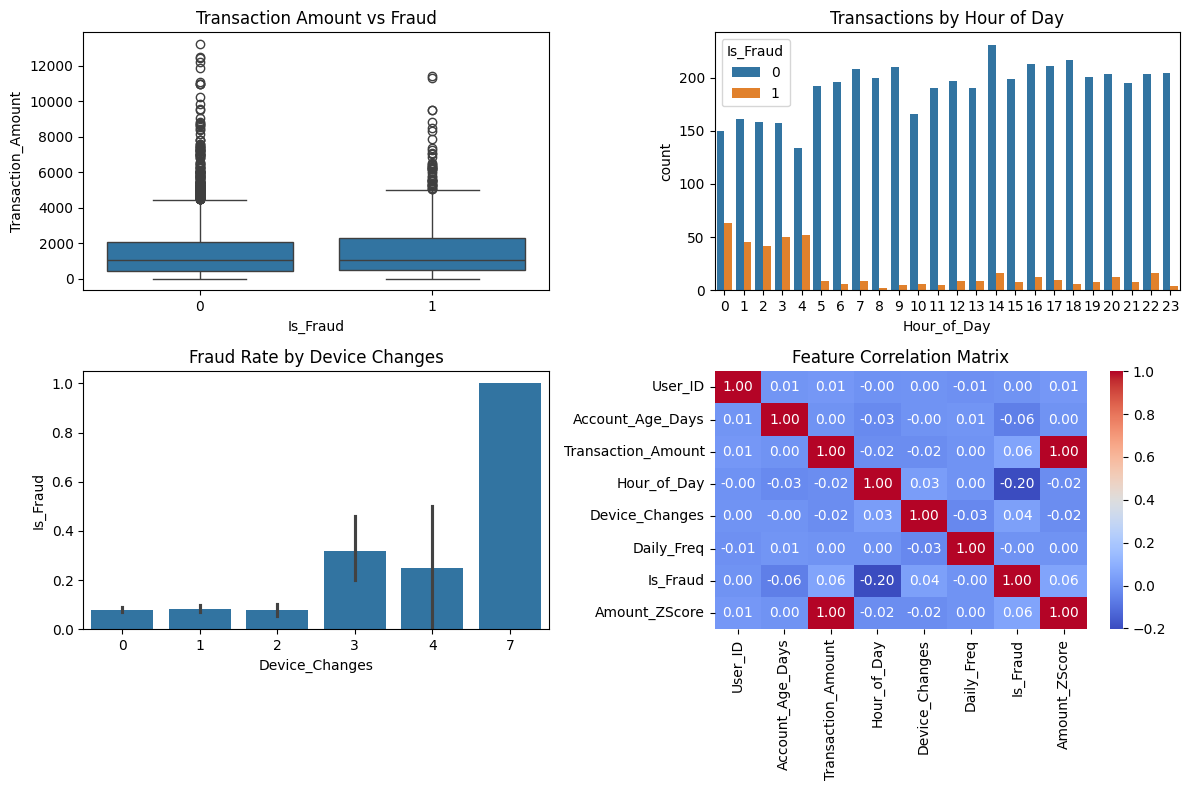

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# ==========================================
# GENERATE SYNTHETIC UPI TRANSACTIONS DATA
# ==========================================
def generate_synthetic_data(n_samples=5000):
    user_ids = np.random.randint(1000, 2000, size=n_samples)
    account_age_days = np.random.randint(1, 365, size=n_samples)
    transaction_amount = np.random.exponential(scale=1500, size=n_samples) + 10
    hour_of_day = np.random.randint(0, 24, size=n_samples)
    device_changes = np.random.poisson(lam=0.5, size=n_samples)
    daily_freq = np.random.poisson(lam=3, size=n_samples)

    # Base fraud probability logic to simulate real patterns
    fraud_prob = (
        0.02
        + (transaction_amount > 5000) * 0.15
        + (hour_of_day < 5) * 0.20
        + (device_changes > 2) * 0.25
        + (account_age_days < 30) * 0.10
    )
    fraud_prob = np.clip(fraud_prob, 0, 1)
    is_fraud = np.random.binomial(1, fraud_prob)

    df = pd.DataFrame({
        'Transaction_ID': [f'TXN{i:06d}' for i in range(1, n_samples + 1)],
        'User_ID': user_ids,
        'Account_Age_Days': account_age_days,
        'Transaction_Amount': np.round(transaction_amount, 2),
        'Hour_of_Day': hour_of_day,
        'Device_Changes': device_changes,
        'Daily_Freq': daily_freq,
        'Is_Fraud': is_fraud
    })
    return df

# ==========================================
# PHASE 1: DATA UNDERSTANDING & CLEANING
# ==========================================
print("=== PHASE 1: DATA UNDERSTANDING ===")
df = generate_synthetic_data(5000)

print(f"Total Transactions: {len(df)}")
print(f"Missing Values:\n{df.isnull().sum()}")

# Remove duplicates if any
df = df.drop_duplicates()

fraud_count = df['Is_Fraud'].sum()
fraud_percentage = (fraud_count / len(df)) * 100
print(f"Suspicious (Fraud) Transactions: {fraud_count} ({fraud_percentage:.2f}%)\n")

# ==========================================
# PHASE 2: DESCRIPTIVE STATISTICAL ANALYSIS
# ==========================================
print("=== PHASE 2: DESCRIPTIVE STATISTICS ===")
stats_summary = df[['Transaction_Amount', 'Daily_Freq', 'Account_Age_Days']].agg(
    ['mean', 'median', 'std', lambda x: x.quantile(0.25), lambda x: x.quantile(0.75)]
).rename(index={'<lambda_0>': '25%', '<lambda_1>': '75%'})

print(stats_summary)
print(f"\nAverage Transaction Amount: ₹{df['Transaction_Amount'].mean():.2f}")
print(f"Average Daily Transaction Frequency: {df['Daily_Freq'].mean():.2f}")
print(f"Transaction Amount Skewness: {df['Transaction_Amount'].skew():.2f}\n")

# ==========================================
# PHASE 3: OUTLIER DETECTION INVESTIGATION
# ==========================================
print("=== PHASE 3: OUTLIER DETECTION ===")

# IQR Method for Transaction Amount
Q1 = df['Transaction_Amount'].quantile(0.25)
Q3 = df['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = df[df['Transaction_Amount'] > upper_bound]

# Z-Score Method
df['Amount_ZScore'] = stats.zscore(df['Transaction_Amount'])
z_outliers = df[df['Amount_ZScore'].abs() > 3]

print(f"IQR Upper Bound threshold: ₹{upper_bound:.2f}")
print(f"Outliers detected via IQR: {len(iqr_outliers)}")
print(f"Outliers detected via Z-score (> 3 std dev): {len(z_outliers)}")

# Identify high-risk users based on outliers
unusual_users = df[(df['Transaction_Amount'] > upper_bound) & (df['Device_Changes'] > 2)]
print(f"Statistically unusual user instances (High Amount + High Device Changes): {len(unusual_users)}\n")

# ==========================================
# PHASE 4: PATTERN ANALYSIS (PLOTS)
# ==========================================
plt.figure(figsize=(12, 8))

# 1. Amount Distribution by Fraud Status
plt.subplot(2, 2, 1)
sns.boxplot(x='Is_Fraud', y='Transaction_Amount', data=df)
plt.title('Transaction Amount vs Fraud')

# 2. Fraud by Hour of Day
plt.subplot(2, 2, 2)
sns.countplot(x='Hour_of_Day', hue='Is_Fraud', data=df)
plt.title('Transactions by Hour of Day')

# 3. Device Changes vs Fraud Rate
plt.subplot(2, 2, 3)
sns.barplot(x='Device_Changes', y='Is_Fraud', data=df)
plt.title('Fraud Rate by Device Changes')

# 4. Correlation Heatmap
plt.subplot(2, 2, 4)
numeric_df = df.drop(columns=['Transaction_ID'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.savefig('eda_patterns.png')
print("Visualizations saved to 'eda_patterns.png'.\n")

# ==========================================
# PHASE 5: HYPOTHESIS TESTING
# ==========================================
print("=== PHASE 5: HYPOTHESIS TESTING ===")

# Test 1: Two-sample T-test (Transaction Amount vs Fraud)
# H0: Mean transaction amount is equal for fraud and non-fraud
# H1: Mean transaction amount is different for fraud and non-fraud
fraud_amounts = df[df['Is_Fraud'] == 1]['Transaction_Amount']
normal_amounts = df[df['Is_Fraud'] == 0]['Transaction_Amount']

t_stat, p_val = stats.ttest_ind(fraud_amounts, normal_amounts)
print("1. Two-sample T-Test (Amount vs Fraud):")
print(f"   t-statistic: {t_stat:.4f}, p-value: {p_val:.4e}")
if p_val < 0.05:
    print("   Result: Reject Null Hypothesis. Transaction amount significantly impacts fraud.\n")
else:
    print("   Result: Fail to reject Null Hypothesis.\n")

# Test 2: Chi-Square Test (Device Changes vs Fraud)
contingency_table = pd.crosstab(df['Device_Changes'], df['Is_Fraud'])
chi2, p_val_chi2, _, _ = stats.chi2_contingency(contingency_table)
print("2. Chi-Square Test (Device Changes vs Fraud):")
print(f"   chi2-statistic: {chi2:.4f}, p-value: {p_val_chi2:.4e}")
if p_val_chi2 < 0.05:
    print("   Result: Reject Null Hypothesis. Device changes are significantly associated with fraud.\n")

# ==========================================
# PHASE 6 & 7: FRAUD SIGNALS & BUSINESS INSIGHTS
# ==========================================
print("=== PHASE 6 & 7: FRAUD SIGNALS & BUSINESS RECOMMENDATIONS ===")
print("""
Ranked Fraud Signals by Severity:
1. Frequent Device Swapping (>2 changes): Strongest statistical signal for unauthorized access.
2. Off-Hours Spike (Midnight - 5 AM): High concentration of fraudulent behavior during non-standard hours.
3. High Amount Outliers on New Accounts (<30 days old): Unusually high transfers on fresh accounts.

Key Recommendations:
- Implement Multi-Factor Authentication (MFA) whenever a device change is detected.
- Apply step-up authentication or delayed settlement for high-value transactions between 12 AM and 5 AM.
- Enforce dynamic transaction limits during the first 30 days of account creation.
""")